# Archivo para calcular rentabilidad de un portafolio

In [1]:
##### Modulos necesarios
import pandas as pd
import numpy as np
from tqdm import tqdm
import scipy
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# Rentabilidad equilibrada

Por varias razones, una rentabilidad equilibrada es necesaria para medir diferences mas equitativamente. La formula es

$R_t = \sum_i^n \frac{\sigma_{tgt}}{\tilde{\sigma}_{i,t-1}} * w_{i,t-1} * r_{i,t} - C*\sum_i^n | \frac{\sigma_{tgt}}{\tilde{\sigma}_{i,t-1}} * w_{i,t-1} - \frac{\sigma_{tgt}}{\tilde{\sigma}_{i,t-2}} * w_{i,t-2} |$

Los requisitos para calcular esta rentabilidad son:
- Rendimientos: $r_{i,t}$
- Pesas del portafolio: $w_{i,t}$
- Exponentially Weighted Moving Standar Deviation (EWMSD): $\tilde{\sigma}_{i,t-1}$
- Constantes - volatilidad deseada $\sigma_{tgt}$ y costo de transacciones $C$

El EWMA generalmente se calcula en la siguiente manera:

$\text{EWMA}_t(x) = \alpha * x_t + (1-\alpha) * \text{EWMA}_{t-1}(x)$

Implicando que el EWMSD es:

$\tilde{\sigma}_{i,t} = \sqrt{\alpha(r_t-\mu_{t-1})^2 + (1-\alpha)\tilde{\sigma}_{t-1}^2}$


In [2]:
##### Funcion para integrar posiciones
def posiciones(df_r: pd.DataFrame, empresas: list[str], tipo:str):
    df_posiciones = pd.DataFrame()
    #### Extracciones individuales
    if tipo=='sliding':
        for i in range(22):
            tmp = scipy.io.loadmat(f'SlidingFinalPreds/pred_sliding_{i}.mat')
            df_tmp = pd.DataFrame(tmp['Ypred_final'])
            df_posiciones = pd.concat([df_posiciones, df_tmp], axis=0, ignore_index=True)
        del tmp
        df_posiciones.columns = [f'Posicion.{nom}' for nom in empresas]
    elif tipo=='expanding':
        for i in range(22):
            tmp = scipy.io.loadmat(f'ExpandingFinalPreds/pred_expanding_{i}.mat')
            df_tmp = pd.DataFrame(tmp['Ypred_final'])
            df_posiciones = pd.concat([df_posiciones, df_tmp], axis=0, ignore_index=True)
        del tmp
        df_posiciones.columns = [f'Posicion.{nom}' for nom in empresas]
    elif tipo=='todo':
        for nom in empresas:
            df_posiciones[f'Posicion.{nom}'] = [1] * df_r.shape[0]
    elif tipo=='rand':
        import random
        random.seed(42)
        for nom in empresas:
            df_posiciones[f'Posicion.{nom}'] = [random.randint(0,1) for _ in range(df_r.shape[0])]


    #### Asegurando que df_posiciones tenga mismo numero de datos
    df_posiciones = df_posiciones.iloc[:df_r.shape[0]]

    #### Camiando indices
    df_posiciones.index = df_r.index
    
    #### Sumando cantidad de posiciones
    suma = df_posiciones.sum(axis=1)

    #### Asignando posiciones equitativamente
    df_posiciones_finales = df_posiciones.div(suma, axis=0)

    #### Integrando posiciones con rendimientos
    df_integrado = pd.concat([df_r,df_posiciones_finales], axis=1, ignore_index=False)

    return df_integrado


In [ ]:
##### Calculando formula para la rentabilidad del portafolio

def calc_rentabilidad(df:pd.Dataframe, empresas: list[str], tgt: int = 0.1, costo : int = 0.00001) -> pd.Dataframe:
    """
    Formula para calcular la rentabilidad de un portafolio 

    Params:
    df: el dataframe que contiene los rendimientos, EWMSD, y posiciones del portafolio
    tgt: la voltatilidad deseada para escalar la volatilidad proporcionalmente
    costo: costo de cambiar las posiciones de las acciones en un portafolio

    Return:
    df_rentabilidad: el df que contiene la rentabilidad del portafolio por las fechas marcadas
    """
    #### Calculando rentabilidad equitativa por cada accion/empresa
    df_rentabilidad = pd.DataFrame()
    for name in empresas:
        df_rentabilidad[f'Rentabilidad.{name}'] = df[name] * (tgt/df[f'EWMSD.{name}'].shift(1))  * df[f'Posicion.{name}'].shift(1) - \
        costo*abs(((tgt/df[f'EWMSD.{name}'].shift(1))*df[f'Posicion.{name}'].shift(1)) - ((tgt/df[f'EWMSD.{name}'].shift(2))*df[f'Posicion.{name}'].shift(2)))
        # df_rentabilidad[f'Rentabilidad.{name}'] = df[name] * df[f'Posicion.{name}']


    #### Elimando primera dos fila por el "shift(2)"
    df_rentabilidad = df_rentabilidad.iloc[2:]

    #### Sumando la rentabilidad de todas las acciones para calcular la rentabilidad diaria del portafolio
    df_rentabilidad_diaria = df_rentabilidad.sum(axis=1)
    # df_rentabilidad_diaria = df_rentabilidad

    return df_rentabilidad_diaria



In [4]:
##### Creando datos necesarios
#### Rendimientos, origiales y logs
df_rendis = pd.read_csv('retornos.csv', index_col='Date')

#### Nombre de las 32 empresas
empresas = df_rendis.columns.to_list()

#### Calculando EWMSD
for name in empresas:
    df_rendis[f'EWMSD.{name}'] = df_rendis[name].ewm(span=30, adjust=False).std()
    # df_rendis[f'EWMSD.{name}']  = [1] * df_rendis.shape[0]    #Debug
    # df_rendis[f'Posicion.{name}'] = [1] * df_rendis.shape[0]  #Posiciones falsas para debug
    # df_rendis[f'Rentabilidad.{name}'] = df_rendis[name] * (1/df_rendis[f'EWMSD.{name}'].shift(1))  *df_rendis[f'Posicion.{name}'].shift(1) - \
    # 1*abs(((1/df_rendis[f'EWMSD.{name}'].shift(1))*df_rendis[f'Posicion.{name}'].shift(1)) - ((1/df_rendis[f'EWMSD.{name}'].shift(2))*df_rendis[f'Posicion.{name}'].shift(2)))
    #     #Simulando rentabilidad calculacion

#### Eliminando datos
### Al crear la particion de los datos
    # Bajo "matlab_procesamiento", no se completo el ultimo conjunto porque solo tenia 62
            # dias y le faltaban 160 mas
df_rendis = df_rendis.iloc[:-62]
### Al separar los datos en train/val/test
    # El trainset tiene 252 dias y el valset tiene 63
    # Adicionalmente, los siguiente 30 dias no se consideran porque se utilizaron para
            # crear la primera ventana del testset
    # Entonces los primeros 252 + 63 + 30 = 345 dias se eliminan
df_rendis = df_rendis.iloc[345:]


#### Para hacer debug
# df_rendis.to_csv('mod_retornos.csv', index=True, encoding='utf-8')
# df_rendis.iloc[:,:32].to_csv('mod_retornos3.csv', index=True, encoding='utf-8')


In [17]:
##### Analisis con rendimientos originales
#### Calculando posiciones
df_sliding = posiciones(df_rendis, empresas, 'sliding')
df_expanding = posiciones(df_rendis, empresas, 'expanding')
df_todo= posiciones(df_rendis, empresas, 'todo')
df_rand = posiciones(df_rendis, empresas, 'rand')


# df = df_todo.loc['2026-03-02':'2026-03-10']
# stat = df.std(axis=0, ddof=0)
# stat.to_clipboard(excel=True, sep=None)
# display(df_todo.loc['2026-03-10':].head(10))
# df_todo.loc['2026-03-18'].to_clipboard(excel=True, sep=None)


#### Calculado rentabilidades diarias
sliding_rentabilidad_diaria = calc_rentabilidad(df_sliding, empresas)
expanding_rentabilidad_diaria = calc_rentabilidad(df_expanding, empresas)
todo_rentabilidad_diaria = calc_rentabilidad(df_todo, empresas)
rand_rentabilidad_diaria = calc_rentabilidad(df_rand, empresas)


display(todo_rentabilidad_diaria.head())
# todo_rentabilidad_diaria.to_csv('rentabilidad_todos')


#### Calculando y trazando rentabilidad acumulada
### Calculacion
sliding_rentabilidad_acumulada = (1 + sliding_rentabilidad_diaria).cumprod() - 1
expanding_rentabilidad_acumulada = (1 + expanding_rentabilidad_diaria).cumprod() - 1
todo_rentabilidad_acumulada = (1 + todo_rentabilidad_diaria).cumprod() - 1
rand_rentabilidad_acumulada = (1 + rand_rentabilidad_diaria).cumprod() - 1

,Rentabilidad.ABEV,Rentabilidad.AC,Rentabilidad.AMXB,Rentabilidad.AXIA3,Rentabilidad.BAP,Rentabilidad.BBAS3,Rentabilidad.BBD,Rentabilidad.BIMBOA,Rentabilidad.BSAC,Rentabilidad.CEMEXCPO,...,Rentabilidad.PBR,Rentabilidad.PBR-A,Rentabilidad.RENT3,Rentabilidad.SBSP3,Rentabilidad.SCCO,Rentabilidad.SQM,Rentabilidad.VALE,Rentabilidad.VIV,Rentabilidad.WALMEX,Rentabilidad.WEGE3
Date,,,,,,,,,,,,,,,,,,,,,
2007-06-28,3.394830e-03,-2.684321e-07,-9.343096e-08,2.810860e-03,4.750782e-03,0.001385,6.049756e-04,0.001381,3.433935e-03,0.001593,...,9.756757e-04,9.147340e-04,0.001410,-0.003205,5.527008e-03,2.276461e-03,-1.174796e-03,2.819735e-04,0.000279,0.001253
2007-06-29,1.934633e-03,-2.775506e-07,-6.212316e-03,3.136918e-04,-3.489659e-04,-0.000071,3.109786e-04,0.002603,3.203980e-03,-0.001525,...,1.543025e-04,4.783610e-04,-0.001942,0.001309,1.744115e-03,2.705738e-03,1.688526e-03,-9.700385e-05,0.000718,0.006880
2007-07-02,-4.501925e-04,-2.869777e-07,3.134049e-03,-5.862081e-08,4.381354e-03,0.002268,3.014627e-03,-0.004142,3.736015e-03,0.001671,...,7.213176e-03,6.531636e-03,0.009397,0.002642,7.589737e-03,4.376924e-03,5.499796e-03,1.301376e-03,0.001521,0.006249
2007-07-03,6.981458e-04,-2.967239e-07,4.215388e-03,-5.698199e-03,-6.654736e-04,0.003841,7.565395e-04,0.002342,1.968074e-03,0.006443,...,4.116159e-03,3.028805e-03,0.001494,0.004336,-1.265918e-03,-1.279977e-03,3.153074e-04,7.537089e-03,0.001741,-0.000093
2007-07-04,-5.463213e-08,-3.068001e-07,-3.524195e-08,-1.244630e-03,-4.495243e-08,-0.000217,-5.051672e-08,-0.000447,-8.388531e-08,-0.002888,...,-4.611361e-09,-3.357284e-08,0.000528,0.001045,-2.821615e-08,-3.576174e-08,-4.498598e-08,-1.666818e-07,0.001056,0.001821


In [6]:
# ##### Visualizaciones
# ### Grafo Completo
# SALTO_X = 222   #252 test dias - 30 dias ventana tamano
# ANCHURA = 50
# ALTURA = 25

# fig, ax = plt.subplots(figsize=(ANCHURA, ALTURA))

# ### Sliding_acumulada
# ax.plot(
#     sliding_rentabilidad_acumulada.index,
#     sliding_rentabilidad_acumulada,
#     color='blue',
#     label = 'MATLAB_LSTM_sliding',
#     linestyle = 'solid'
# )

# ### Expanding acumulada
# ax.plot(
#     expanding_rentabilidad_acumulada.index,
#     expanding_rentabilidad_acumulada,
#     color='green',
#     label = 'MATLAB_LSTM_expanding',
#     linestyle = 'solid'
# )

# ### Todo-portafolio acumulada
# ax.plot(
#     todo_rentabilidad_acumulada.index,
#     todo_rentabilidad_acumulada,
#     color='orange',
#     label = 'Todo-portafolio',
#     linestyle = 'solid'
# )

# ### Rand-portafolio acumulada
# ax.plot(
#     rand_rentabilidad_acumulada.index,
#     rand_rentabilidad_acumulada,
#     color='red',
#     label = 'Rand-portafolio',
#     linestyle = 'solid'
# )

# ### configuraciones
# ax.set_title('Rentabilidad acumulada',fontsize = ANCHURA)
# ax.set_ylabel('Valor Acumulado (%)', fontsize = ANCHURA, labelpad = ALTURA)
# ax.set_xlabel('Fechas', fontsize =ANCHURA, labelpad = ANCHURA)
# ax.tick_params(axis='x', labelsize=0.75*ANCHURA, rotation=70) 
# ax.tick_params(axis='y', labelsize=0.75*ANCHURA) 
# ax.xaxis.set_major_locator(MultipleLocator(SALTO_X))
# ax.legend(fontsize = 0.75*ANCHURA)
# ax.grid(True)


# plt.show()






# ### Grafo Pre-covid
# SALTO_X = 222   #252 test dias - 30 dias ventana tamano
# ANCHURA = 50
# ALTURA = 25

# fig, ax = plt.subplots(figsize=(ANCHURA, ALTURA))

# ### Sliding_acumulada
# ax.plot(
#     sliding_rentabilidad_acumulada.loc[:"2020-04-02"].index,
#     sliding_rentabilidad_acumulada.loc[:"2020-04-02"],
#     color='blue',
#     label = 'MATLAB_LSTM_sliding',
#     linestyle = 'solid'
# )

# ### Expanding acumulada
# ax.plot(
#     expanding_rentabilidad_acumulada.loc[:"2020-04-02"].index,
#     expanding_rentabilidad_acumulada.loc[:"2020-04-02"],
#     color='green',
#     label = 'MATLAB_LSTM_expanding',
#     linestyle = 'solid'
# )

# ### Todo-portafolio acumulada
# ax.plot(
#     todo_rentabilidad_acumulada.loc[:"2020-04-02"].index,
#     todo_rentabilidad_acumulada.loc[:"2020-04-02"],
#     color='orange',
#     label = 'Todo-portafolio',
#     linestyle = 'solid'
# )

# ### Rand-portafolio acumulada
# ax.plot(
#     rand_rentabilidad_acumulada.loc[:"2020-04-02"].index,
#     rand_rentabilidad_acumulada.loc[:"2020-04-02"],
#     color='red',
#     label = 'Rand-portafolio',
#     linestyle = 'solid'
# )

# ### configuraciones
# ax.set_title('Rentabilidad acumulada - pre COVID',fontsize = ANCHURA)
# ax.set_ylabel('Valor Acumulado (%)', fontsize = ANCHURA, labelpad = ALTURA)
# ax.set_xlabel('Fechas', fontsize =ANCHURA, labelpad = ANCHURA)
# ax.tick_params(axis='x', labelsize=0.75*ANCHURA, rotation=70) 
# ax.tick_params(axis='y', labelsize=0.75*ANCHURA) 
# ax.xaxis.set_major_locator(MultipleLocator(SALTO_X))
# ax.legend(fontsize = 0.75*ANCHURA)
# ax.grid(True)


# plt.show()












# ### Grafo Poscovid
# SALTO_X = 222   #252 test dias - 30 dias ventana tamano
# ANCHURA = 50
# ALTURA = 25

# fig, ax = plt.subplots(figsize=(ANCHURA, ALTURA))

# ### Sliding_acumulada
# ax.plot(
#     sliding_rentabilidad_acumulada.loc["2020-04-02":].index,
#     sliding_rentabilidad_acumulada.loc["2020-04-02":],
#     color='blue',
#     label = 'MATLAB_LSTM_sliding',
#     linestyle = 'solid'
# )

# ### Expanding acumulada
# ax.plot(
#     expanding_rentabilidad_acumulada.loc["2020-04-02":].index,
#     expanding_rentabilidad_acumulada.loc["2020-04-02":],
#     color='green',
#     label = 'MATLAB_LSTM_expanding',
#     linestyle = 'solid'
# )

# ### Todo-portafolio acumulada
# ax.plot(
#     todo_rentabilidad_acumulada.loc["2020-04-02":].index,
#     todo_rentabilidad_acumulada.loc["2020-04-02":],
#     color='orange',
#     label = 'Todo-portafolio',
#     linestyle = 'solid'
# )

# ### Rand-portafolio acumulada
# ax.plot(
#     rand_rentabilidad_acumulada.loc["2020-04-02":].index,
#     rand_rentabilidad_acumulada.loc["2020-04-02":],
#     color='red',
#     label = 'Rand-portafolio',
#     linestyle = 'solid'
# )

# ### configuraciones
# ax.set_title('Rentabilidad acumulada - pos COVID',fontsize = ANCHURA)
# ax.set_ylabel('Valor Acumulado (%)', fontsize = ANCHURA, labelpad = ALTURA)
# ax.set_xlabel('Fechas', fontsize =ANCHURA, labelpad = ANCHURA)
# ax.tick_params(axis='x', labelsize=0.75*ANCHURA, rotation=70) 
# ax.tick_params(axis='y', labelsize=0.75*ANCHURA) 
# ax.xaxis.set_major_locator(MultipleLocator(SALTO_X))
# ax.legend(fontsize = 0.75*ANCHURA)
# ax.grid(True)


# plt.show()



In [7]:
##### Funcion para calculcar el ratio Sharpe
def ratio_sharpe(df: pd.DataFrame, periodo_por_ano: int = 252):
    """
    df: dataframe con todas las rentabilidades acumuladas de todas estrategias
    periodo_por_ano: cuantos datos se encuentran en un ano
    """
    nom_cols = [f'Ratio.{nom}' for nom in df.columns]
    df_ratios = pd.DataFrame(columns=(['Fecha_comienzo','Fecha_terminar'] + nom_cols))

    #### Configurando datos para que sean divisibles por "periodo_por_ano"
    dias_sobrantes = df.shape[0] % periodo_por_ano
    df = df.iloc[dias_sobrantes:]

    #### Guardando datos para calcular ratio Sharpe final
    ratios_totales = []

    #### Calculando ratios
    for i in range(0, df.shape[0], periodo_por_ano):
        ### Extrayendo fechas
        comienzo = df.iloc[i].name
        termino = df.iloc[i+periodo_por_ano-1].name
        periodo = df.iloc[i:i+periodo_por_ano]

        ### Calculando el promedio y volatilidad
        promedio = periodo.mean(axis=0)
        vol = periodo.std(axis=0, ddof=1)
        annualized_promedio = promedio * periodo_por_ano
        annualized_vol = vol* np.sqrt(periodo_por_ano)
        ### Calculando ratio
        ratios = annualized_promedio/(annualized_vol + 1e-8)
        ratios_list = ratios.to_numpy().tolist()
        ratios_totales.append(ratios_list)
        df_ratios.loc[len(df_ratios)] = [comienzo, termino] + ratios_list

    #### Encontrando promedio rato sharpe de todo tiempo
    primera_fecha = df_ratios['Fecha_comienzo'].iloc[0]
    ultima_fecha = df_ratios['Fecha_terminar'].iloc[-1]

    df_ratios.loc[len(df_ratios)] = [primera_fecha, ultima_fecha] + np.array(ratios_totales).mean(axis=0).tolist()

    return df_ratios


In [8]:
##### Calculando el ratio Sharpe
#### Arregalndo portafolios
portafolios = [sliding_rentabilidad_diaria, expanding_rentabilidad_diaria, todo_rentabilidad_diaria, rand_rentabilidad_diaria]
port_noms = ['sliding', 'expanding', 'todo', 'rand']

#### Creando dataframe con todos portafolios
df_rentabilidades = pd.DataFrame(index=portafolios[0].index)
for i in range(len(portafolios)):
    df_rentabilidades[port_noms[i]] = portafolios[i]

df_ratios = ratio_sharpe(df_rentabilidades)

display(df_ratios)

,Fecha_comienzo,Fecha_terminar,Ratio.sliding,Ratio.expanding,Ratio.todo,Ratio.rand
0,2007-11-07,2008-10-23,-0.868874,-0.666951,-1.523654,-1.496595
1,2008-10-24,2009-10-12,2.877119,2.635735,2.853392,2.784630
2,2009-10-13,2010-09-29,1.479686,0.519666,1.223720,1.017787
3,2010-09-30,2011-09-16,-0.023433,0.475629,-0.087845,0.029393
4,2011-09-19,2012-09-04,0.700379,0.902989,0.519986,0.248337
5,2012-09-05,2013-08-22,-0.206395,-0.846859,0.044128,-0.015265
6,2013-08-23,2014-08-11,0.699840,1.164722,1.151103,0.817949
7,2014-08-12,2015-07-29,-0.647123,-1.304964,-1.023328,-0.653810
8,2015-07-30,2016-07-15,0.756839,0.813919,0.827001,1.037121
9,2016-07-18,2017-07-04,1.386218,1.225237,1.528531,1.438578


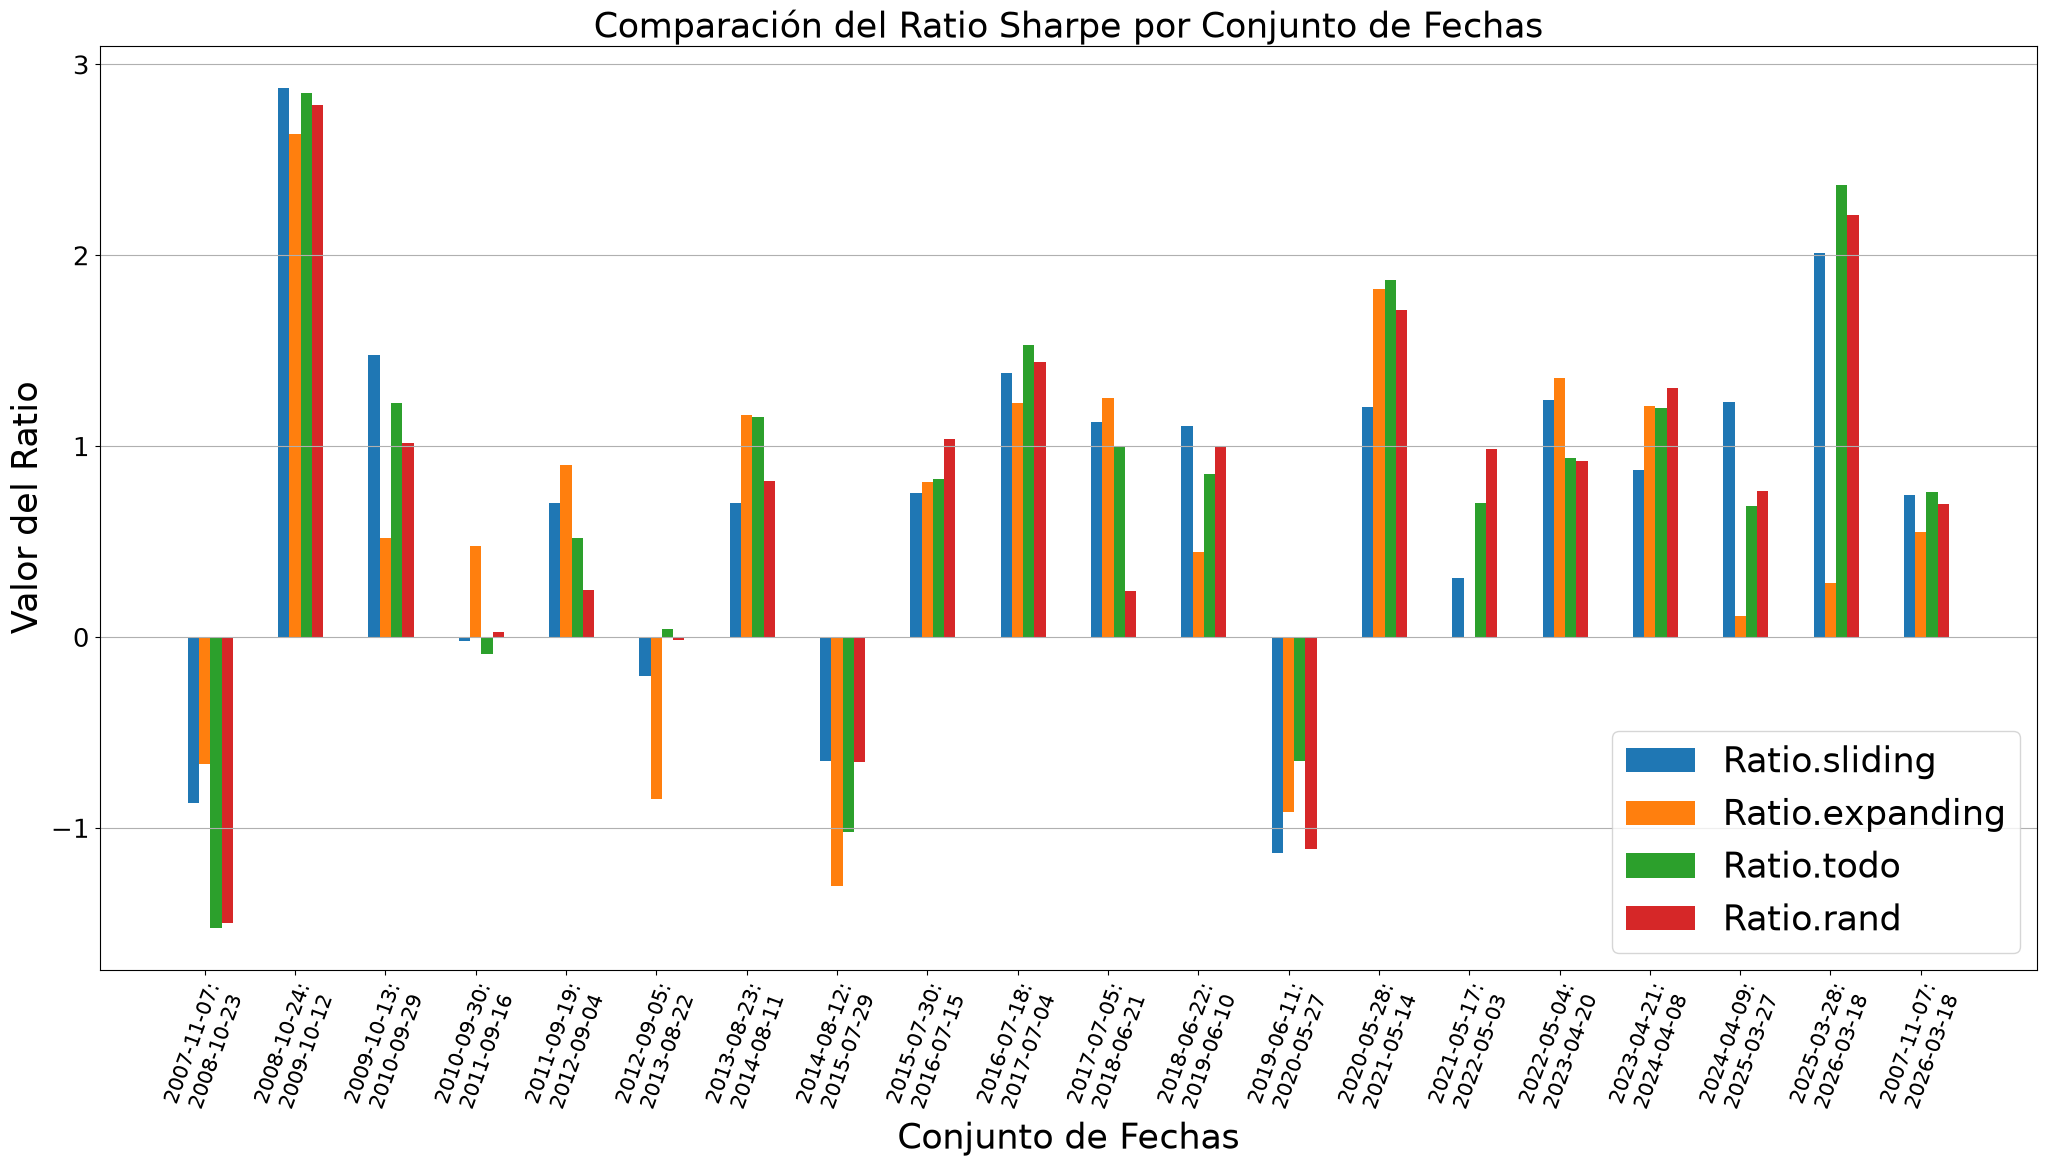

In [9]:
##### Transformar df_ratios en tabla imagen

#### Preparando dataset para tabla
df_ratios_aju = df_ratios.round(3)
df_ratios_num = df_ratios_aju.select_dtypes(include=[np.number])

#### Asignando colores
cell_colours = [['#A5A2A2','#A5A2A2'] + ["white"] * (len(df_ratios_aju.columns)-2) for _ in range(len(df_ratios_aju))]
cell_colours[-1] = ["#A5A2A2", '#A5A2A2']  + ["#52EE86"]* (len(df_ratios_aju.columns)-2)
    # Ultima fila otro color

#### Buscando maximos y pintar amarillo
# max_idxs = df_ratios_num.idxmax(axis=1)
max_idxs = df_ratios_num.values.argmax(axis=1)
for i in range(len(max_idxs)):
    cell_colours[i][max_idxs[i]+2] = 'yellow'


#### Crear figura
fig, ax = plt.subplots(figsize=(len(df_ratios_aju.columns) * 1.2, len(df_ratios_aju) * 0.5 + 1))
ax.axis('off')
### Crear tabla
tabla = ax.table(
    cellText=df_ratios_aju.values,
    colLabels=df_ratios_aju.columns,
    # rowLabels=df_ratios_aju.index,
    cellColours=cell_colours,
    cellLoc="center",
    loc="center",
)

### Ajustar tamaño del texto automáticamente
tabla.auto_set_font_size(False)
tabla.set_fontsize(8)
tabla.scale(1, 1.5)


### Guardar imagen
# plt.savefig('df_ratios.png', bbox_inches="tight", dpi=300)
plt.close() 


#### Creando bar graph
### Hiperparams
ANCHURA = 25
ALTURA = 12
WIDTH = 0.125

### Creando Bar graph
cols = df_ratios_aju.iloc[:,2:].columns.to_list()
x = np.arange(len(df_ratios_aju.index.to_list()))    #Posiciones base
fig, ax = plt.subplots(figsize=(ANCHURA, ALTURA))
for i, col in enumerate(cols):
    ax.bar(x + i * WIDTH, df_ratios_aju[col], WIDTH, label=col)

### Creando x index
x_idxs = [a + ":\n" + b for a,b in zip(df_ratios_aju['Fecha_comienzo'].values, df_ratios_aju['Fecha_terminar'].values)]

### Configurando bar graph
ax.set_xlabel('Conjunto de Fechas', fontsize=ANCHURA)
ax.set_ylabel('Valor del Ratio', fontsize=ANCHURA)
ax.set_title('Comparación del Ratio Sharpe por Conjunto de Fechas', fontsize=ANCHURA)
ax.set_xticks(x + WIDTH)
ax.set_xticklabels(x_idxs)
ax.grid(True, axis='y')
ax.tick_params(axis='x', labelsize=0.6*ANCHURA, rotation=70) 
ax.tick_params(axis='y', labelsize=0.75*ANCHURA) 
ax.legend(fontsize=ANCHURA)


In [10]:
# ##### Tranzando rentabilidad diaria
# #### Grafo
# SALTO_X = 222   #252 test dias - 30 dias ventana tamano
# ANCHURA = 50
# ALTURA = 25

# fig, ax = plt.subplots(figsize=(ANCHURA, ALTURA))

# #### Sliding_acumulada
# ax.plot(
#     sliding_rentabilidad_diaria.index,
#     sliding_rentabilidad_diaria,
#     color='blue',
#     label = 'MATLAB_LSTM_sliding',
#     linestyle = 'solid'
# )

# #### Expanding acumulada
# ax.plot(
#     expanding_rentabilidad_diaria.index,
#     expanding_rentabilidad_diaria,
#     color='green',
#     label = 'MATLAB_LSTM_expanding',
#     linestyle = 'solid'
# )

# # #### Todo-portafolio acumulada
# # ax.plot(
# #     todo_rentabilidad_diaria.index,
# #     todo_rentabilidad_diaria,
# #     color='orange',
# #     label = 'Todo-portafolio',
# #     linestyle = 'solid'
# # )

# #### Rand-portafolio acumulada
# ax.plot(
#     rand_rentabilidad_diaria.index,
#     rand_rentabilidad_diaria,
#     color='red',
#     label = 'Rand-portafolio',
#     linestyle = 'solid'
# )


# ax.set_title('Rentabilidad diaria',fontsize = ANCHURA)
# ax.set_ylabel('Valor Acumulado (%)', fontsize = ANCHURA, labelpad = ALTURA)
# ax.set_xlabel('Fechas', fontsize =ANCHURA, labelpad = ANCHURA)
# ax.tick_params(axis='x', labelsize=0.75*ANCHURA, rotation=70) 
# ax.tick_params(axis='y', labelsize=0.75*ANCHURA) 
# ax.xaxis.set_major_locator(MultipleLocator(SALTO_X))
# ax.legend(fontsize = 0.75*ANCHURA)
# ax.grid(True)

# plt.show()

In [11]:
# ##### Analisis con rendimientos logaritmicos
# #### Calculando posiciones
# df_sliding = posiciones(df_rendis_log, empresas, 'sliding')
# df_expanding = posiciones(df_rendis_log, empresas, 'expanding')
# df_todo= posiciones(df_rendis_log, empresas, 'todo')
# df_rand = posiciones(df_rendis_log, empresas, 'rand')

# #### Calculado rentabilidades diarias
# sliding_rentabilidad_diaria = calc_rentabilidad(df_sliding, empresas)
# expanding_rentabilidad_diaria = calc_rentabilidad(df_expanding, empresas)
# todo_rentabilidad_diaria = calc_rentabilidad(df_todo, empresas)
# rand_rentabilidad_diaria = calc_rentabilidad(df_rand, empresas)

# #### Calculando y trazando rentabilidad acumulada
# ### Calculacion
# sliding_rentabilidad_acumulada = (1 + sliding_rentabilidad_diaria).cumprod() - 1
# expanding_rentabilidad_acumulada = (1 + expanding_rentabilidad_diaria).cumprod() - 1
# todo_rentabilidad_acumulada = (1 + todo_rentabilidad_diaria).cumprod() - 1
# rand_rentabilidad_acumulada = (1 + rand_rentabilidad_diaria).cumprod() - 1


# ### Grafo
# SALTO_X = 222   #252 test dias - 30 dias ventana tamano
# ANCHURA = 50
# ALTURA = 25

# fig, ax = plt.subplots(figsize=(ANCHURA, ALTURA))

# ### Sliding_acumulada
# ax.plot(
#     sliding_rentabilidad_acumulada.index,
#     sliding_rentabilidad_acumulada,
#     color='blue',
#     label = 'MATLAB_LSTM_sliding',
#     linestyle = 'solid'
# )

# ### Expanding acumulada
# ax.plot(
#     expanding_rentabilidad_acumulada.index,
#     expanding_rentabilidad_acumulada,
#     color='green',
#     label = 'MATLAB_LSTM_expanding',
#     linestyle = 'solid'
# )

# ### Todo-portafolio acumulada
# ax.plot(
#     todo_rentabilidad_acumulada.index,
#     todo_rentabilidad_acumulada,
#     color='orange',
#     label = 'Todo-portafolio',
#     linestyle = 'solid'
# )

# ### Rand-portafolio acumulada
# ax.plot(
#     rand_rentabilidad_acumulada.index,
#     rand_rentabilidad_acumulada,
#     color='red',
#     label = 'Rand-portafolio',
#     linestyle = 'solid'
# )

# ### configuraciones
# ax.set_title('Rentabilidad logaritmica acumulada',fontsize = ANCHURA)
# ax.set_ylabel('Valor Acumulado (%)', fontsize = ANCHURA, labelpad = ALTURA)
# ax.set_xlabel('Fechas', fontsize =ANCHURA, labelpad = ANCHURA)
# ax.tick_params(axis='x', labelsize=0.75*ANCHURA, rotation=70) 
# ax.tick_params(axis='y', labelsize=0.75*ANCHURA) 
# ax.xaxis.set_major_locator(MultipleLocator(SALTO_X))
# ax.legend(fontsize = 0.75*ANCHURA)
# ax.grid(True)

# plt.show()





In [12]:
# ##### DEBUG ---- Creando datos necesarios
# #### Rendimientos
# df_rendis = pd.read_csv('retornos.csv', index_col='Date')

# empresas = df_rendis.columns.to_list()
# print(empresas)
# sums = df_rendis.sum(axis=1)
# display(sums)

# #### EWMSD
# # df = pd.DataFrame({'valor': [10, 20, 15, 25, 30]})
# # resultado = df.ewm(span=30, adjust=False).std()

# for name in df_rendis.columns:
#     # df_rendis[f'EWMSD.{name}'] = df_rendis[name].ewm(span=30, adjust=False).std()   # Verdadero
#     df_rendis[f'EWMSD.{name}']  = [1] * df_rendis.shape[0]  #Debug
#     df_rendis[f'Posicion.{name}'] = [1] * df_rendis.shape[0]  #Debug

# # display(df_rendis.head())

# #Form 1
# form1 = pd.DataFrame(index=df_rendis.index)
# # for name in empresas:
# #     form1[name] = df_rendis[name]*df_rendis[f'Posicion.{name}'].shift(2)

# # display(form1.sum(axis=1))

# # Form 2
# # for name in empresas:
# #     form1[name] = df_rendis[name] * (0.1/df_rendis[f'EWMSD.{name}'].shift(3))  *df_rendis[f'Posicion.{name}'].shift(2)


# # display(form1.sum(axis=1))


# # Form 4
# for name in empresas:
#     form1[name] = df_rendis[name] * (1/df_rendis[f'EWMSD.{name}'].shift(1))  *df_rendis[f'Posicion.{name}'].shift(1) - \
#     1*abs(((1/df_rendis[f'EWMSD.{name}'].shift(1))*df_rendis[f'Posicion.{name}'].shift(1)) - ((1/df_rendis[f'EWMSD.{name}'].shift(2))*df_rendis[f'Posicion.{name}'].shift(2)))

# display(form1.sum(axis=1))
